# Importation des données

In [33]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import math

# Pairplot

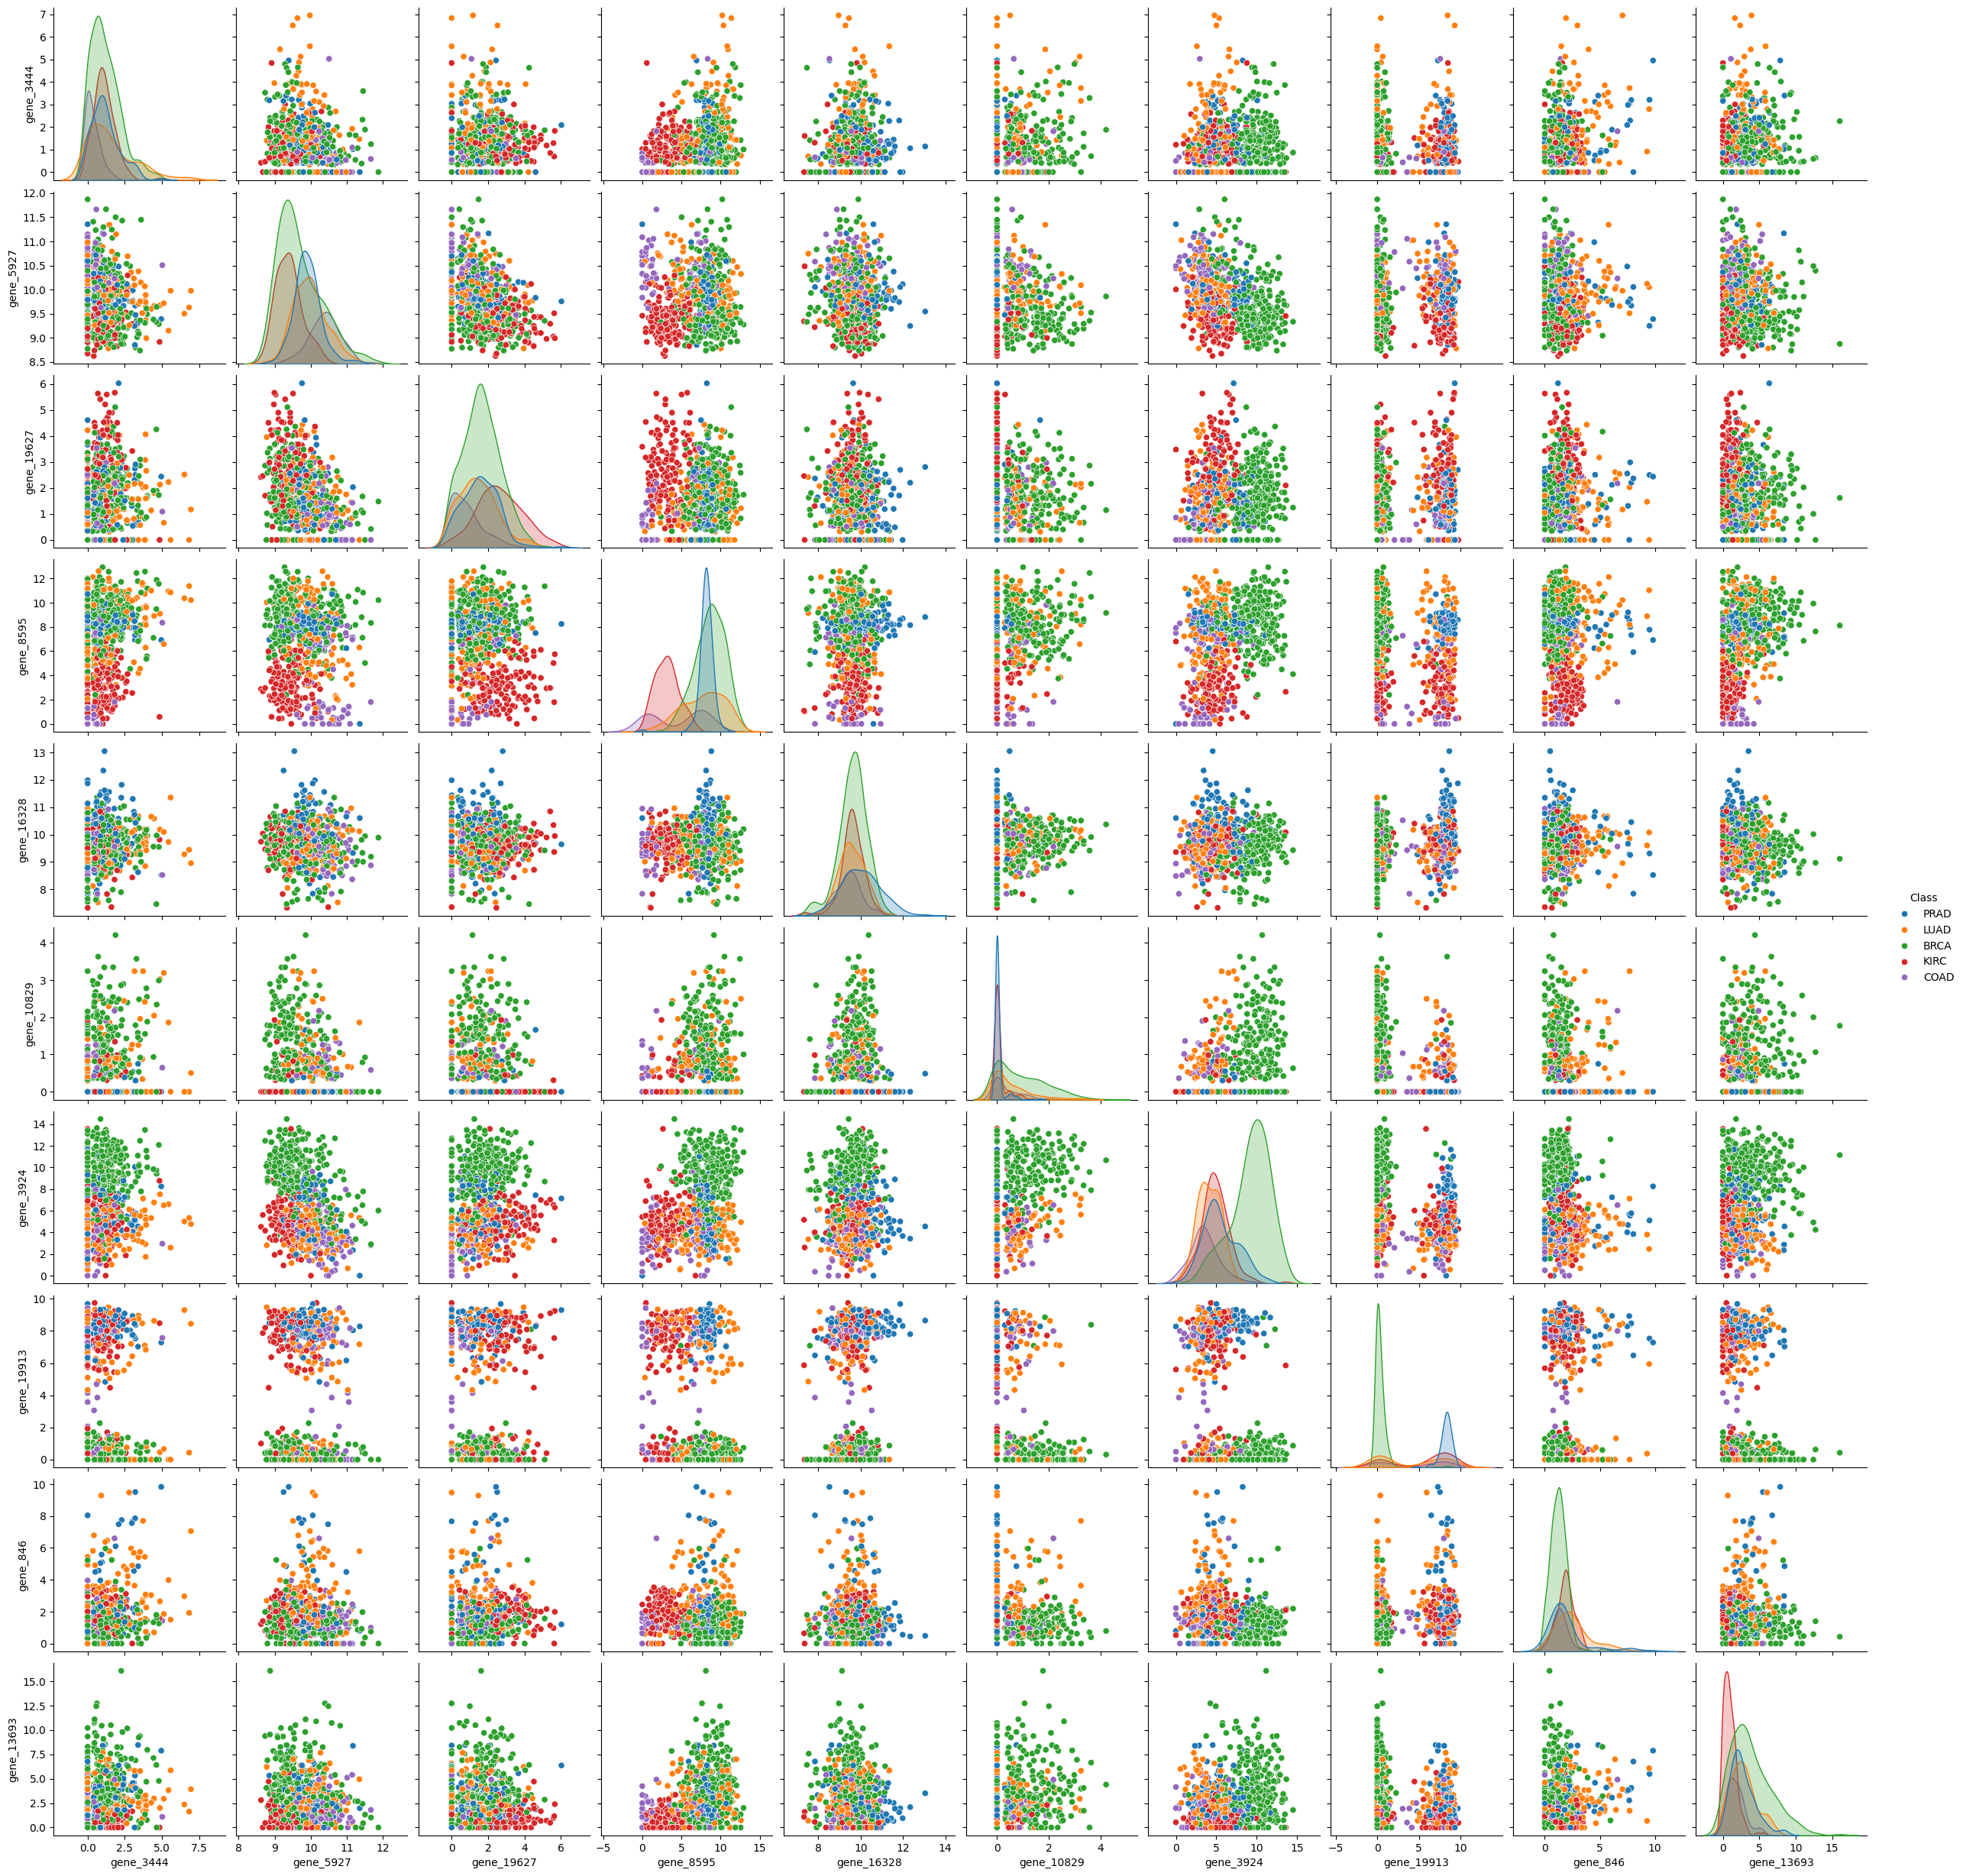

In [10]:
##Visualisation des données avec un pairplot
data = pd.read_csv("data/sample_10_1.csv")
data = data.drop(columns=["Unnamed: 0"])
sns.pairplot(data, hue='Class')

# Pie chart

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


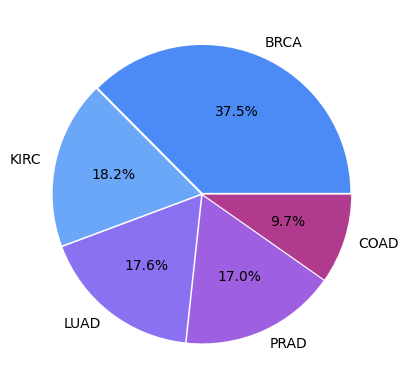

In [21]:
class_counts = data['Class'].value_counts()
print(class_counts)

##Création du pie chart
colors = ['#4C8BF5', '#6BA7F8', '#8A71F2', '#9E60E0', '#B03B8E']
explode = (0.01, 0.01, 0.01, 0.01, 0.01)
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=colors, explode=explode)
plt.show()

# Boxplot

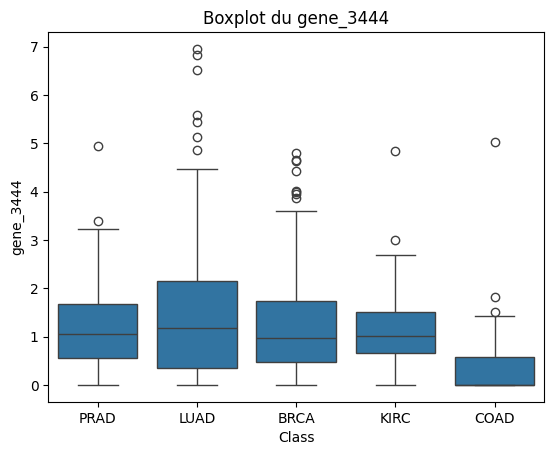

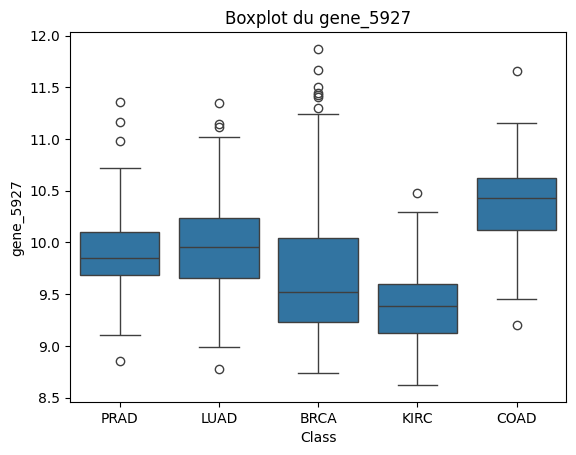

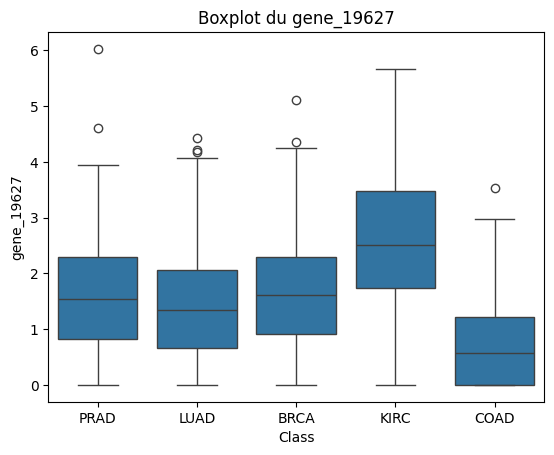

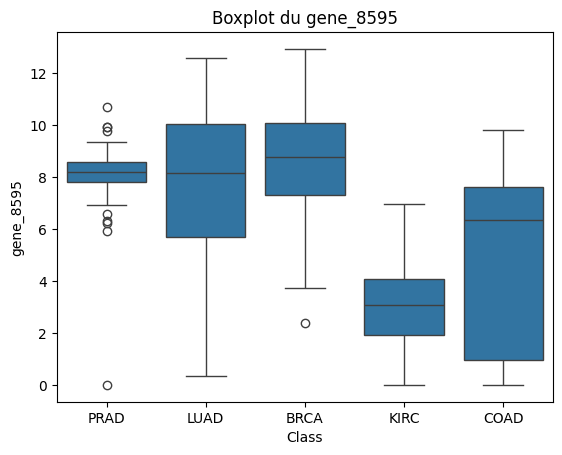

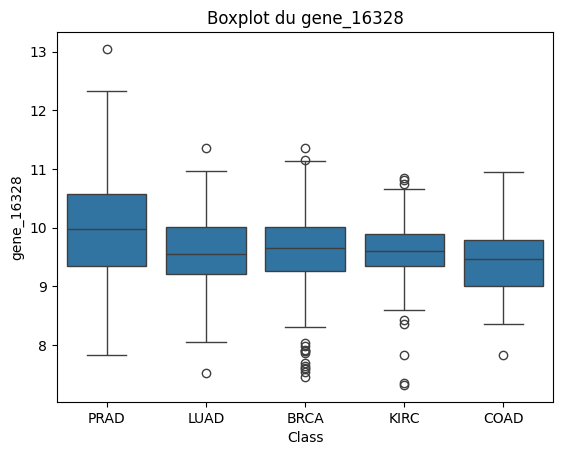

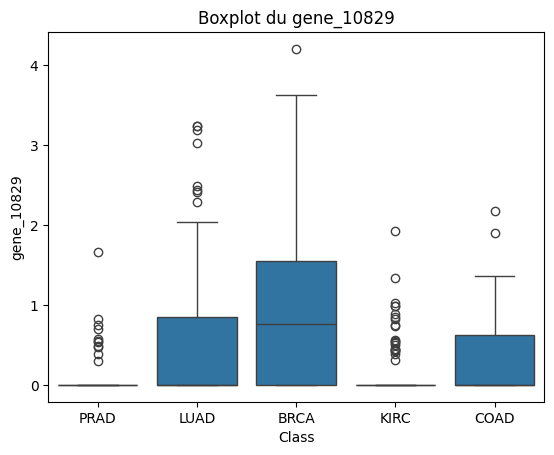

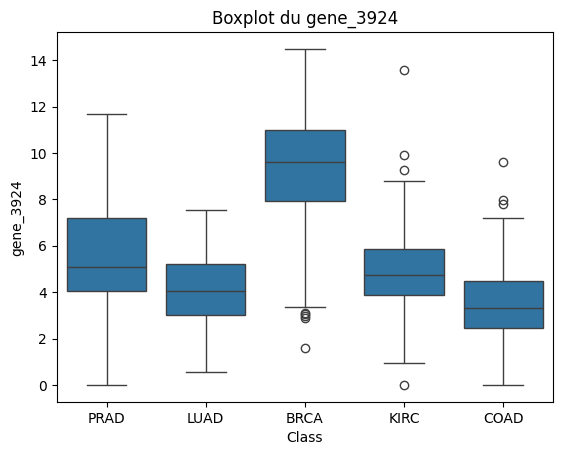

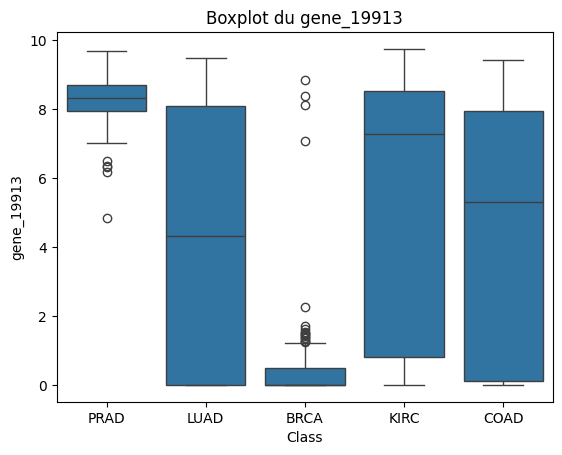

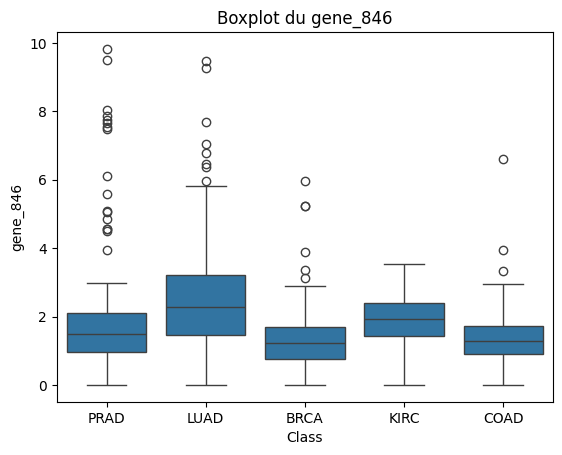

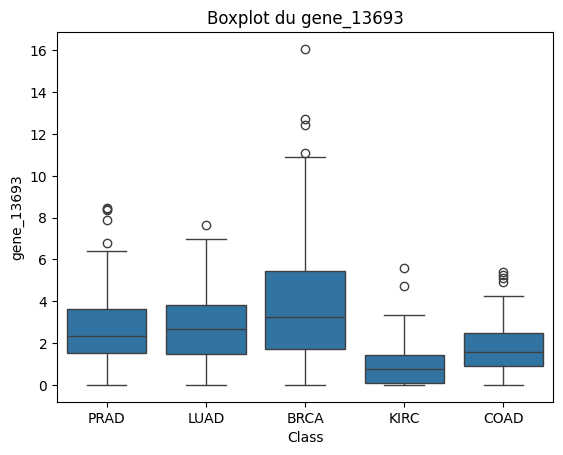

In [ ]:
##Visualisation des donnees avec des boxplots
for columns in data.columns :
    if (columns != "Class") :
        plt.figure()
        sns.boxplot( x=data["Class"], y=data[columns] )
        plt.title(f"Boxplot du {columns}")
        plt.show()

# Spider Plot

In [40]:
# Calcul de la moyenne de la variance pour chaque cancer et chaque gène
mean_by_class = data.groupby('Class').mean()
#mean_by_class.head()
print(mean_by_class)

       gene_3444  gene_5927  gene_19627  gene_8595  gene_16328  gene_10829  \
Class                                                                        
BRCA    1.191852   9.691523    1.649106   8.612456    9.616896    0.943396   
COAD    0.378435  10.387137    0.798753   4.593849    9.425708    0.350176   
KIRC    1.097731   9.395107    2.645413   3.125092    9.587317    0.108764   
LUAD    1.562941   9.977494    1.442560   7.755937    9.573801    0.531184   
PRAD    1.181371   9.904634    1.570680   8.125260   10.027678    0.053281   

       gene_3924  gene_19913  gene_846  gene_13693  
Class                                               
BRCA    9.254421    0.388255  1.263191    3.817278  
COAD    3.564572    4.303630  1.386671    1.744861  
KIRC    4.860430    5.496159  1.878093    0.932033  
LUAD    4.090644    3.991771  2.615492    2.784558  
PRAD    5.537405    8.252482  1.999715    2.713784  


C:\Users\Bulle\AppData\Local\Temp\ipykernel_16904\3254047858.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(data.index))


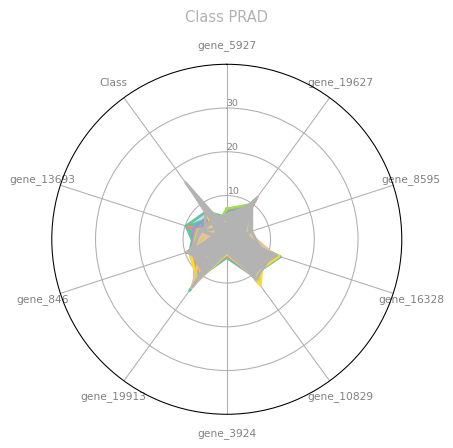

In [47]:
# Spider_plot_V3
from math import pi

# Voici un exemple de structure de `mean_by_class` :
# Class  | var1 | var2 | var3 | ... | var10
# Class1 | 10   | 20   | 30   | ... | 25
# Class2 | 15   | 25   | 35   | ... | 30

# ------- PART 1: Define a function that do a plot for one line of the dataset!
def make_spider(row, title, color, categories, df):

    # number of variables
    N = len(categories)

    # Angle de chaque axe dans le plot (diviser l'angle complet par le nombre de variables)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Fermer le cercle

    # Initialisation du plot radar
    ax = plt.subplot(2, 2, 4, polar=True) #row +1

    # Si tu veux que le premier axe soit en haut :
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Tracer les axes et les étiquettes
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    # Tracer les labels y
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30], ["10", "20", "30"], color="grey", size=7)
    plt.ylim(0, 40)

    # Prendre les valeurs de la ligne (classe) et les adapter
    values = data.loc[row].drop('Class').values.flatten().tolist()
    values += values[:1]  # Fermer le cercle

    # Tracer la ligne et remplir la zone
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)

    # Ajouter un titre
    plt.title(title, size=11, color=color, y=1.1)

# ------- PART 2: Apply the function to all classes (groupes)
# Initialiser la figure
my_dpi = 96
plt.figure(figsize=(1000 / my_dpi, 1000 / my_dpi), dpi=my_dpi)

# Palette de couleurs : il nous faut autant de couleurs que de classes
my_palette = plt.cm.get_cmap("Set2", len(data.index))

# On boucle sur chaque classe (chaque ligne du DataFrame)
for row in range(0, len(data.index)):
    make_spider(row=row, title='Class ' + data['Class'][row], color=my_palette(row), categories=data.columns[1:], df=data)

# Affichage du plot
plt.show()

In [31]:
from math import pi

L_mean = [mean_by_class[k] for k in range(len(mean_by_class))]

 
# number of variable
categories=list(mean_by_class)[1:]
N = len(categories)
 
# We are going to plot the first line of the data frame.
# But we need to repeat the first value to close the circular graph:
values=mean_by_class.loc[0].drop('group').values.flatten().tolist()
values += values[:1]
values
 
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
ax = plt.subplot(111, polar=True)
 
# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories, color='grey', size=8)
 
# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([10,20,30], ["10","20","30"], color="grey", size=7)
plt.ylim(0,40)
 
# Plot data
ax.plot(angles, values, linewidth=1, linestyle='solid')
 
# Fill area
ax.fill(angles, values, 'b', alpha=0.1)

# Show the graph
plt.show()

KeyError: 0

# Répartition des variances

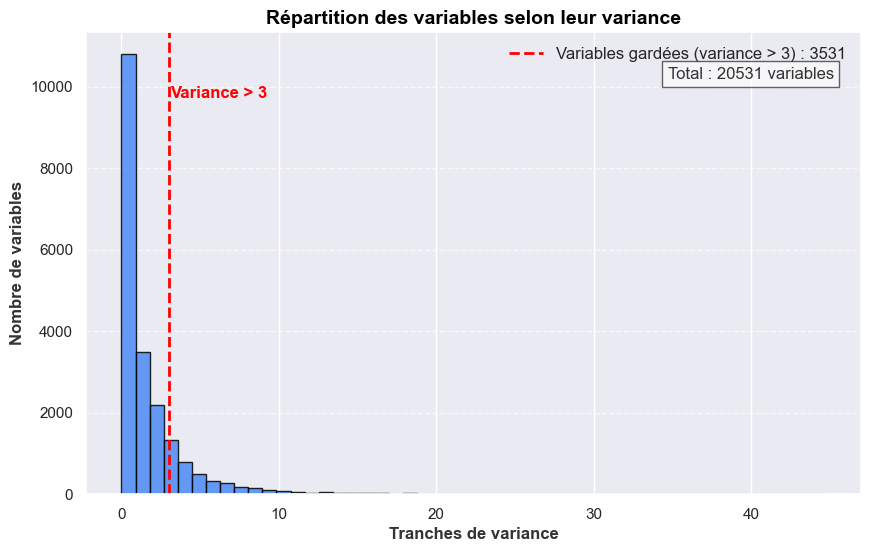

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme() 

data = pd.read_csv('data/data.csv.gz', compression='gzip')
data = data.drop(columns=['Unnamed: 0'])

# Calcul de la variance de chaque variable (colonnes)
variances = data.var(axis=0)

# Nombre de variables avec une variance > 3
variables_gardees = np.sum(variances > 3)

# Taille du graphique
plt.figure(figsize=(10, 6))

# Création de l'histogramme avec le bleu demandé
plt.hist(variances, bins=50, color='#4C8BF5', alpha=0.85, edgecolor='black')

# Ajout des labels et titre avec une meilleure mise en forme
plt.xlabel("Tranches de variance", fontsize=12, fontweight='bold', color='#333333')
plt.ylabel("Nombre de variables", fontsize=12, fontweight='bold', color='#333333')
plt.title("Répartition des variables selon leur variance", fontsize=14, fontweight='bold', color='black')

# Limite de la tranche 3
limite_2_3 = 3

# Ajouter une droite rouge en pointillés à la limite de la tranche 2-3
plt.axvline(x=limite_2_3, color='red', linestyle='--', linewidth=2)

# Ajouter une annotation pour la ligne
plt.text(limite_2_3 + 0.1, max(np.histogram(variances, bins=50)[0]) * 0.9, 
         'Variance > 3', color='red', fontsize=12, fontweight='bold')

# Ajouter la légende avec le nombre de variables gardées
plt.legend([f"Variables gardées (variance > 3) : {variables_gardees}"], loc='upper right', fontsize=12, frameon=False)

# Ajout d’annotations : nombre total de variables
plt.annotate(f"Total : {len(variances)} variables", xy=(0.75, 0.9), xycoords="axes fraction", 
             fontsize=12, color='#333333', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black'))

# Ajout d’une grille discrète pour la lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage
plt.show()
